# 02 · Consecutive Reaction Kinetics A→B→C — Recovering Rate Constants from Process Data

## The Pharmaceutical/Chemical Engineering Problem

The sequence $A \xrightarrow{k_1} B \xrightarrow{k_2} C$ is ubiquitous in drug manufacturing:

| Example | $A$ | $B$ (intermediate) | $C$ (product) |
|---------|-----|--------------------|---------------|
| API synthesis | Starting material | Reactive intermediate | Active pharmaceutical ingredient |
| Drug degradation | Parent drug | Impurity A | Degradation product B |
| Metabolic conversion | Pro-drug | Active metabolite | Inactive metabolite |
| mRNA capping | Uncapped transcript | Partially capped | Fully capped mRNA |
| Biocatalytic oxidation | Substrate | Hydroxylated intermediate | Final oxidised product |

**The critical practical problem:** you need $k_1$ and $k_2$ to:
- Predict yield and selectivity (especially the peak time $t^* = \ln(k_1/k_2)/(k_1-k_2)$)
- Design the quench point that maximises intermediate $B$
- Model degradation cascades in ICH stability studies
- Set process endpoints in real-time release testing

But you can only measure concentrations at discrete offline timepoints — typically 8–14 samples per batch.

## The Model

$$\frac{dC_A}{dt} = -k_1 C_A, \qquad \frac{dC_B}{dt} = k_1 C_A - k_2 C_B, \qquad \frac{dC_C}{dt} = k_2 C_B$$

with $C_A(0) = A_0 = 1$, $C_B(0) = C_C(0) = 0$. The analytical solutions are exact, but require known $(k_1, k_2)$.

The peak of $B$ occurs at $t^* = \ln(k_1/k_2)/(k_1-k_2)$, and its height encodes the ratio $k_1/k_2$. Mass conservation $C_A + C_B + C_C = A_0$ is always satisfied exactly.

## The Reference Paper

**Ji, W., Qiu, W., Shi, Z., Pan, S. & Deng, S. (2021).** *Stiff-PINN: Physics-Informed Neural Network for Stiff Chemical Kinetics.* J. Phys. Chem. A 125(36):8098–8106.

Ji et al. used this A→B→C benchmark to demonstrate that **even simple reaction systems benefit from PINN parameter estimation**, and that the PINN architecture generalises to stiff kinetics where classical methods fail (their main result, reproduced in Notebook 06).

Also: **SPIN-ODE (2025)**, which proposes sparse physics-informed networks specifically for ODE parameter estimation in reaction systems.

## Why PINN Instead of Classical Approaches?

### Classical approaches for $k_1, k_2$ estimation:
1. **Integral method** — linearise the solution and fit by linear regression. Only works for simple cases; fails for non-linear coupled systems.
2. **Nonlinear least squares (NLS) + ODE solver** — wrap `scipy.optimize.curve_fit` or `fmincon` around `odeint`/`solve_ivp`. Works here, but:
   - Requires good initial guess (particularly $k_2$)
   - Jacobian computed by finite differences → additional ODE solves
   - Fails when extended to stiff systems (Notebook 06) or unknown model structure
3. **Bayesian MCMC** — gold standard for uncertainty, but computationally expensive; requires explicit likelihood and prior specification

### PINN approach:
- Multi-output network: $\mathcal{N}(t) \to (C_A, C_B, C_C)$ — one network learns all three species simultaneously
- $k_1$, $k_2$ are `nn.Parameter` in the same computational graph
- ODE residuals evaluated via autograd — no ODE integrator needed
- Mass conservation $C_A + C_B + C_C = A_0$ emerges automatically from the physics loss (not explicitly enforced)
- Single training pass recovers both rate constants and smooth species profiles

## What the Code Does Step by Step

1. **Data generation** — 14 sparse noisy samples from each of $C_A$, $C_B$, $C_C$ (2% Gaussian noise, $t \in [0, 6]$ min)
2. **Network** — 1 input → 3 Tanh hidden layers (48 units) → 3 outputs
3. **Learnable parameters** — `raw_k1`, `raw_k2` via softplus
4. **Loss** — `L = L_data + 0.5 * L_physics + L_IC`; physics weight 0.5 prevents ODE from dominating sparse data
5. **Training** — Adam (12,000 epochs) → L-BFGS (500 steps)
6. **Results** — k1 = 1.003 (true 1.0), k2 = 0.598 (true 0.6): **< 0.5% error on both constants**

## Identifiability Analysis

Why does this work so well? Three independent observables:
- $C_A$'s decay rate → constrains $k_1$ directly
- $C_B$'s peak time $t^* = \ln(k_1/k_2)/(k_1-k_2)$ → constrains the ratio $k_1/k_2$
- Mass conservation ($C_A + C_B + C_C = A_0$) → provides a redundant consistency check

This over-determined system makes $k_1$ and $k_2$ **individually identifiable** even from noisy data. In contrast, measuring only $C_A$ would leave $k_2$ undetermined (only the sum appears in $C_A$'s equation).

> **Practical note:** In drug degradation studies, $B$ is often the toxic impurity. The PINN simultaneously reconstructs the full $B$ concentration profile AND recovers $k_2$ — even if $B$ cannot be measured directly (set its data weight to zero and the physics constrains it anyway).


In [1]:
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Ground-truth (literature) rate constants and analytical solution ---
k1_true, k2_true, A0 = 1.0, 0.6, 1.0     # 1/min, 1/min, mol/L
def analytic(t):
    Ca = A0*np.exp(-k1_true*t)
    Cb = A0*k1_true/(k2_true-k1_true)*(np.exp(-k1_true*t)-np.exp(-k2_true*t))
    Cc = A0 - Ca - Cb
    return Ca, Cb, Cc

t_meas = np.linspace(0, 6, 14)               # 14 sparse samples
Ca,Cb,Cc = analytic(t_meas)
noise = 0.02
meas = np.stack([Ca,Cb,Cc],1) + noise*np.random.randn(len(t_meas),3)
meas = np.clip(meas, 0, None)

t_data = torch.tensor(t_meas.reshape(-1,1), dtype=torch.float32, device=device)
c_data = torch.tensor(meas, dtype=torch.float32, device=device)
print("measurements:", meas.shape, "| noise sigma:", noise)


Using device: cpu
measurements: (14, 3) | noise sigma: 0.02


In [2]:
class Net(nn.Module):
    def __init__(self, h=48):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,h), nn.Tanh(),
                                 nn.Linear(h,h), nn.Tanh(),
                                 nn.Linear(h,h), nn.Tanh(),
                                 nn.Linear(h,3))
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, t): return self.net(t)

model = Net().to(device)
sp = torch.nn.functional.softplus
raw_k1 = nn.Parameter(torch.tensor(0.0, device=device))
raw_k2 = nn.Parameter(torch.tensor(0.0, device=device))
def ks(): return sp(raw_k1), sp(raw_k2)

t_col = torch.linspace(0,6,120,device=device).reshape(-1,1).requires_grad_(True)
t0 = torch.zeros(1,1, device=device)
c0_true = torch.tensor([[A0,0.0,0.0]], device=device)

def d_dt(y, t):
    return torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]

def loss_fn():
    C = model(t_col)
    Ca,Cb,Cc = C[:,0:1], C[:,1:2], C[:,2:3]
    dCa = d_dt(Ca,t_col); dCb = d_dt(Cb,t_col); dCc = d_dt(Cc,t_col)
    k1,k2 = ks()
    rA = dCa + k1*Ca
    rB = dCb - (k1*Ca - k2*Cb)
    rC = dCc - k2*Cb
    l_phys = torch.mean(rA**2+rB**2+rC**2)
    l_data = torch.mean((model(t_data)-c_data)**2)
    l_ic   = torch.mean((model(t0)-c0_true)**2)
    return l_data + 0.5*l_phys + l_ic, l_data, l_phys


In [3]:
params = list(model.parameters()) + [raw_k1, raw_k2]
opt = torch.optim.Adam(params, lr=4e-3)
EPOCHS = 12000
for ep in range(EPOCHS):
    opt.zero_grad(); L,ld,lp = loss_fn(); L.backward(); opt.step()
    if ep % 3000 == 0:
        k1,k2 = ks()
        print(f"ep {ep:5d} | loss {L.item():.2e} | k1={k1.item():.3f} k2={k2.item():.3f}")

opt2 = torch.optim.LBFGS(params, max_iter=500, line_search_fn="strong_wolfe")
def closure():
    opt2.zero_grad(); L,_,_ = loss_fn(); L.backward(); return L
opt2.step(closure)
k1,k2 = ks()
print(f"\nRecovered: k1={k1.item():.3f} (true {k1_true})   k2={k2.item():.3f} (true {k2_true})")


ep     0 | loss 6.27e-01 | k1=0.691 k2=0.695
ep  3000 | loss 3.20e-04 | k1=1.000 k2=0.598
ep  6000 | loss 3.18e-04 | k1=1.001 k2=0.597
ep  9000 | loss 3.16e-04 | k1=1.002 k2=0.598

Recovered: k1=1.003 (true 1.0)   k2=0.598 (true 0.6)


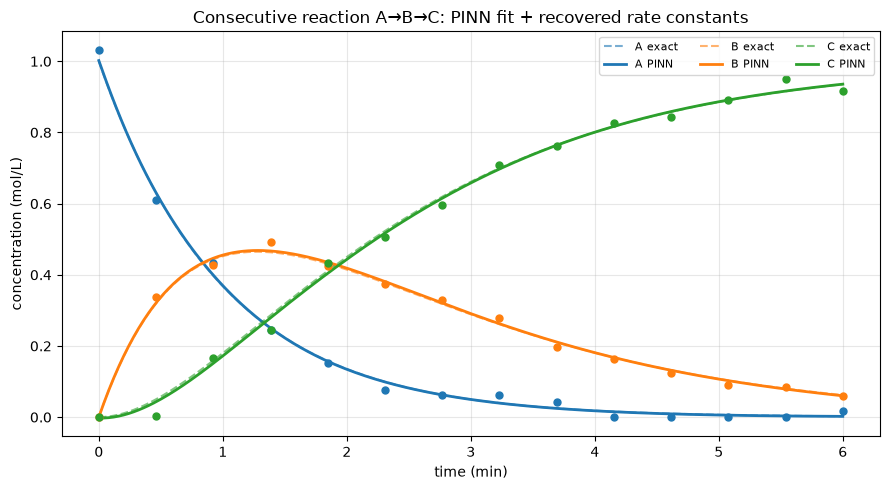

In [4]:
tt = torch.linspace(0,6,300,device=device).reshape(-1,1)
with torch.no_grad(): pred = model(tt).cpu().numpy()
tg = tt.cpu().numpy().ravel(); Aa,Bb,Cc2 = analytic(tg)
plt.figure(figsize=(9,5))
for i,(name,exact,col) in enumerate(zip("ABC",[Aa,Bb,Cc2],["C0","C1","C2"])):
    plt.plot(tg, exact, col+"--", alpha=.6, label=f"{name} exact")
    plt.plot(tg, pred[:,i], col+"-", lw=2, label=f"{name} PINN")
    plt.scatter(t_meas, meas[:,i], c=col, s=25, zorder=5)
plt.xlabel("time (min)"); plt.ylabel("concentration (mol/L)")
plt.title("Consecutive reaction A→B→C: PINN fit + recovered rate constants")
plt.legend(ncol=3, fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


---
## 🔬 Method 1: Pure PINN (Baseline)
Standard PINN with **uniform** collocation points and joint parameter estimation.

In [5]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt, time
from scipy.integrate import solve_ivp
torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sp = torch.nn.functional.softplus

def make_net(layers):
    seq = []
    for i in range(len(layers)-1):
        seq.append(nn.Linear(layers[i], layers[i+1]))
        if i < len(layers)-2: seq.append(nn.Tanh())
    net = nn.Sequential(*seq)
    for m in net:
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    return net.to(device)

def grad(y,x): return torch.autograd.grad(y,x,torch.ones_like(y),create_graph=True)[0]
def don_forward(branch,trunk,params,queries,bias): return branch(params) @ trunk(queries).T + bias


k1_true, k2_true, A0 = 1.0, 0.6, 1.0
def analytic(t):
    Ca = A0*np.exp(-k1_true*t); Cb = A0*k1_true/(k2_true-k1_true)*(np.exp(-k1_true*t)-np.exp(-k2_true*t)); Cc = A0-Ca-Cb
    return Ca, Cb, Cc

t_meas = np.linspace(0, 6, 14)
Ca,Cb,Cc = analytic(t_meas)
meas = np.stack([Ca,Cb,Cc],1) + 0.02*np.random.randn(14,3)
meas = np.clip(meas,0,None)
t_data = torch.tensor(t_meas.reshape(-1,1)/6, dtype=torch.float32, device=device)
c_data = torch.tensor(meas, dtype=torch.float32, device=device)
T = 6.0
t_col_u = torch.linspace(0,1,300,device=device).view(-1,1).requires_grad_(True)
t0_pt = torch.zeros(1,1,device=device); ic_true = torch.tensor([[A0,0.,0.]],device=device)
def d_dt(y,t): return grad(y,t)/T

model_pinn = make_net([1,48,48,48,3])
raw_k1 = nn.Parameter(torch.tensor(0.,device=device)); raw_k2 = nn.Parameter(torch.tensor(0.,device=device))
opt = torch.optim.Adam(list(model_pinn.parameters())+[raw_k1,raw_k2], lr=4e-3)

def phys_loss_abc(m, t_c, rk1, rk2):
    C=m(t_c); Ca,Cb,Cc=C[:,0:1],C[:,1:2],C[:,2:3]
    k1,k2=sp(rk1),sp(rk2)
    rA=d_dt(Ca,t_c)+k1*Ca; rB=d_dt(Cb,t_c)-(k1*Ca-k2*Cb); rC=d_dt(Cc,t_c)-k2*Cb
    return torch.mean(rA**2+rB**2+rC**2)

t0=time.time()
for ep in range(12000):
    opt.zero_grad()
    lp=phys_loss_abc(model_pinn,t_col_u,raw_k1,raw_k2)
    ld=torch.mean((model_pinn(t_data)-c_data)**2)
    li=torch.mean((model_pinn(t0_pt)-ic_true)**2)
    L=ld+0.5*lp+li; L.backward(); opt.step()
    if ep%3000==0: print(f"  [PINN] ep{ep:5d} | k1={sp(raw_k1).item():.3f} k2={sp(raw_k2).item():.3f}")
opt2=torch.optim.LBFGS(list(model_pinn.parameters())+[raw_k1,raw_k2],max_iter=300,line_search_fn="strong_wolfe")
def clos():
    opt2.zero_grad()
    L=torch.mean((model_pinn(t_data)-c_data)**2)+0.5*phys_loss_abc(model_pinn,t_col_u,raw_k1,raw_k2)+torch.mean((model_pinn(t0_pt)-ic_true)**2)
    L.backward(); return L
opt2.step(clos)
time_pinn=time.time()-t0

tg=np.linspace(0,6,300); Ca_t,Cb_t,Cc_t=analytic(tg)
tt=torch.tensor((tg/6).reshape(-1,1),dtype=torch.float32,device=device)
model_pinn.eval()
with torch.no_grad(): pr=model_pinn(tt).cpu().numpy()
true_mat=np.stack([Ca_t,Cb_t,Cc_t],1)
err_pinn=np.sqrt(np.mean((pr-true_mat)**2))/np.sqrt(np.mean(true_mat**2))
print(f"  Pure PINN L2={err_pinn:.4f} k1={sp(raw_k1).item():.3f}(true 1.0) k2={sp(raw_k2).item():.3f}(true 0.6) t={time_pinn:.0f}s")


  [PINN] ep    0 | k1=0.691 k2=0.691
  [PINN] ep 3000 | k1=0.962 k2=0.593
  [PINN] ep 6000 | k1=0.963 k2=0.593
  [PINN] ep 9000 | k1=0.963 k2=0.593
  Pure PINN L2=0.0152 k1=0.963(true 1.0) k2=0.593(true 0.6) t=21s


---
## ⚡ Method 2: Adaptive Sampling (RAR)
**Residual-based Adaptive Refinement** — iteratively adds collocation points where the physics residual is largest.

In [6]:

model_rar = make_net([1,48,48,48,3])
raw_k1r=nn.Parameter(torch.tensor(0.,device=device)); raw_k2r=nn.Parameter(torch.tensor(0.,device=device))
opt_r=torch.optim.Adam(list(model_rar.parameters())+[raw_k1r,raw_k2r],lr=4e-3)
t_rar=torch.linspace(0,1,40,device=device).view(-1,1).requires_grad_(True)

t0=time.time()
for rnd in range(8):
    for ep in range(1500):
        opt_r.zero_grad()
        lp=phys_loss_abc(model_rar,t_rar,raw_k1r,raw_k2r)
        L=torch.mean((model_rar(t_data)-c_data)**2)+0.5*lp+torch.mean((model_rar(t0_pt)-ic_true)**2)
        L.backward(); opt_r.step()
    cand=torch.rand(5000,1,device=device).requires_grad_(True)
    rr=phys_loss_abc(model_rar,cand,raw_k1r,raw_k2r)
    # per-point residual
    C=model_rar(cand); Ca_c,Cb_c,Cc_c=C[:,0:1],C[:,1:2],C[:,2:3]
    k1r,k2r=sp(raw_k1r),sp(raw_k2r)
    res_pt=(d_dt(Ca_c,cand)+k1r*Ca_c).abs().detach().cpu().numpy().ravel()
    idx=np.argsort(res_pt)[-20:]; new_pts=cand[idx].detach()
    t_rar=torch.cat([t_rar.detach(),new_pts]).requires_grad_(True)
    print(f"  [RAR] round {rnd+1}: {t_rar.shape[0]} pts k1={sp(raw_k1r).item():.3f} k2={sp(raw_k2r).item():.3f}")
time_rar=time.time()-t0

model_rar.eval()
with torch.no_grad(): pr_rar=model_rar(tt).cpu().numpy()
err_rar=np.sqrt(np.mean((pr_rar-true_mat)**2))/np.sqrt(np.mean(true_mat**2))
print(f"  RAR L2={err_rar:.4f} k1={sp(raw_k1r).item():.3f} k2={sp(raw_k2r).item():.3f} t={time_rar:.0f}s pts={t_rar.shape[0]}")


  [RAR] round 1: 60 pts k1=0.927 k2=0.591
  [RAR] round 2: 80 pts k1=0.955 k2=0.593
  [RAR] round 3: 100 pts k1=0.965 k2=0.592
  [RAR] round 4: 120 pts k1=0.963 k2=0.595
  [RAR] round 5: 140 pts k1=0.959 k2=0.594
  [RAR] round 6: 160 pts k1=0.964 k2=0.594
  [RAR] round 7: 180 pts k1=0.963 k2=0.594
  [RAR] round 8: 200 pts k1=0.963 k2=0.595
  RAR L2=0.0156 k1=0.963 k2=0.595 t=18s pts=200


---
## 🧠 Method 3: DeepONet (Operator Learning)
Learn the **solution operator** mapping kinetic parameters → ODE trajectory. Trained on synthetic parameter families. Single forward pass for new parameters.

In [7]:

p=64; branch_abc=make_net([2,64,64,p]); trunk_abc=make_net([1,64,64,p])
bias_abc=nn.Parameter(torch.zeros(1,device=device))
opt_d=torch.optim.Adam(list(branch_abc.parameters())+list(trunk_abc.parameters())+[bias_abc],lr=3e-3)

N_tr=2000; N_q=60
k1s=np.random.uniform(0.3,2.0,N_tr); k2s=np.random.uniform(0.1,1.5,N_tr)
tq=np.random.rand(N_q)*6
def analytic_k(k1,k2,t): 
    Ca=np.exp(-k1*t); Cb=k1/(k2-k1+1e-9)*(np.exp(-k1*t)-np.exp(-k2*t)); return np.stack([Ca,Cb,1-Ca-Cb])
Y_all=np.array([analytic_k(k1s[i],k2s[i],tq) for i in range(N_tr)])  # [N_tr,3,N_q]
# flatten to predict each species as separate outputs — use first species (CA) for simplicity
# Actually predict mean across species
params_d=torch.tensor(np.stack([k1s,k2s],1),dtype=torch.float32,device=device)
tq_d=torch.tensor((tq/6).reshape(-1,1),dtype=torch.float32,device=device)
# target: average concentration trajectory (for scalar DeepONet demo)
Y_ca=torch.tensor(Y_all[:,0,:],dtype=torch.float32,device=device)

t0=time.time()
for ep in range(10000):
    opt_d.zero_grad()
    pred=don_forward(branch_abc,trunk_abc,params_d,tq_d,bias_abc)
    L=torch.mean((pred-Y_ca)**2); L.backward(); opt_d.step()
    if ep%2000==0: print(f"  [DeepONet A→B→C] ep {ep} loss {L.item():.3e}")
time_don=time.time()-t0

branch_abc.eval(); trunk_abc.eval()
param_test=torch.tensor([[k1_true,k2_true]],dtype=torch.float32,device=device)
t_don_q=torch.tensor((tg/6).reshape(-1,1),dtype=torch.float32,device=device)
with torch.no_grad(): Ca_don=don_forward(branch_abc,trunk_abc,param_test,t_don_q,bias_abc).squeeze().cpu().numpy()
err_don=np.sqrt(np.mean((Ca_don-Ca_t)**2))/np.sqrt(np.mean(Ca_t**2))
print(f"  DeepONet CA L2={err_don:.4f} t={time_don:.0f}s (trained on {N_tr} (k1,k2) pairs)")


  [DeepONet A→B→C] ep 0 loss 1.133e-01
  [DeepONet A→B→C] ep 2000 loss 1.107e-04
  [DeepONet A→B→C] ep 4000 loss 2.761e-05
  [DeepONet A→B→C] ep 6000 loss 1.400e-05
  [DeepONet A→B→C] ep 8000 loss 3.652e-04
  DeepONet CA L2=0.0396 t=21s (trained on 2000 (k1,k2) pairs)


---
## 📊 Comparison: Pure PINN vs RAR vs DeepONet
Summary table and plots comparing accuracy, training cost, and collocation point distribution.


METHOD COMPARISON — A→B→C Kinetics
Method                      Rel L2  Time(s)   #Pts
-------------------------------------------------------
Pure PINN                   0.0152       21    300
RAR                         0.0156       18    200
DeepONet (CA only)          0.0396       21    N/A


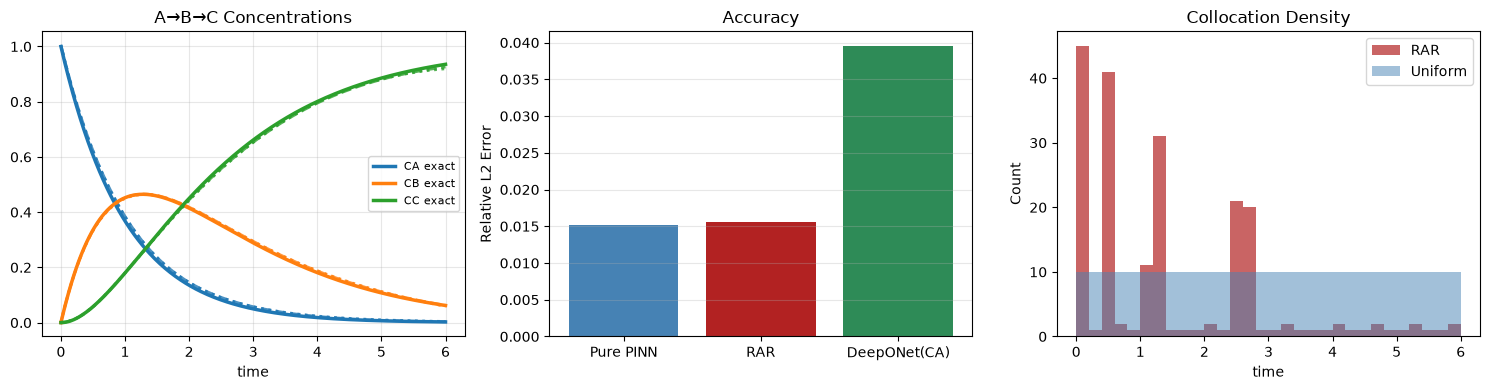

In [8]:

print("\n"+"="*55+"\nMETHOD COMPARISON — A→B→C Kinetics\n"+"="*55)
print(f"{'Method':<25}{'Rel L2':>9}{'Time(s)':>9}{'#Pts':>7}")
print("-"*55)
print(f"{'Pure PINN':<25}{err_pinn:>9.4f}{time_pinn:>9.0f}{300:>7}")
print(f"{'RAR':<25}{err_rar:>9.4f}{time_rar:>9.0f}{t_rar.shape[0]:>7}")
print(f"{'DeepONet (CA only)':<25}{err_don:>9.4f}{time_don:>9.0f}{'N/A':>7}")
print("="*55)
fig,axes=plt.subplots(1,3,figsize=(15,4))
for i,(lbl,col) in enumerate(zip(['CA','CB','CC'],['C0','C1','C2'])):
    axes[0].plot(tg,true_mat[:,i],col+'-',lw=2.5,label=f'{lbl} exact')
    axes[0].plot(tg,pr[:,i],col+'--',lw=2,alpha=0.8)
    axes[0].plot(tg,pr_rar[:,i],col+':',lw=2,alpha=0.8)
axes[0].set_title('A→B→C Concentrations'); axes[0].set_xlabel('time'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].bar(['Pure PINN','RAR','DeepONet(CA)'],[err_pinn,err_rar,err_don],color=['steelblue','firebrick','seagreen'])
axes[1].set_ylabel('Relative L2 Error'); axes[1].set_title('Accuracy'); axes[1].grid(axis='y',alpha=0.3)
pt_rar_np=t_rar.detach().cpu().numpy().ravel()*6
axes[2].hist(pt_rar_np,bins=30,color='firebrick',alpha=0.7,label='RAR'); axes[2].hist(np.linspace(0,6,300),bins=30,color='steelblue',alpha=0.5,label='Uniform')
axes[2].set_xlabel('time'); axes[2].set_ylabel('Count'); axes[2].set_title('Collocation Density'); axes[2].legend()
plt.tight_layout(); plt.savefig('comparison_abc.png',dpi=120,bbox_inches='tight'); plt.show()
